In [7]:
import os, pandas as pd, numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import os, sys

In [8]:
print(f"Python version: {sys.version}")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]
NumPy version:  2.2.6
Pandas version: 2.3.3


In [9]:
import pltfont # mac 전용 한글 깨짐 라이브러리

# 데이터 불러오기

In [4]:
df_raw =pd.read_csv("/Users/jun/GitStudy/human_A/data/selected_data.csv")

# 데이터 상태 확인

In [12]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 65 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tank_b_level_pct              86400 non-null  float64
 1   zone3_substrate_ec_ds_m       86400 non-null  float64
 2   zone3_substrate_ph            86400 non-null  float64
 3   zone2_substrate_ph            86400 non-null  float64
 4   filter_pressure_in_kpa        86400 non-null  float64
 5   motor_power_kw                86400 non-null  float64
 6   mix_target_ec_ds_m            86400 non-null  float64
 7   zone3_pressure_kpa            86400 non-null  float64
 8   air_temp_c                    86400 non-null  float64
 9   drainage_ratio_pct            86400 non-null  float64
 10  filter_pressure_out_kpa       86400 non-null  float64
 11  cavitation_index              86400 non-null  float64
 12  vibration_bandpower_high      86400 non-null  float64
 13  t

In [53]:
df_raw.describe()

,tank_b_level_pct,zone3_substrate_ec_ds_m,zone3_substrate_ph,zone2_substrate_ph,filter_pressure_in_kpa,motor_power_kw,mix_target_ec_ds_m,zone3_pressure_kpa,air_temp_c,drainage_ratio_pct,...,acoustic_db,zone2_substrate_moisture_pct,bearing_vibration_peak_mm_s,raw_tank_pressure_kpa,suction_pressure_kpa,voltage_v,acid_tank_level_pct,zone1_substrate_ph,pump_rpm,raw_water_temp_c
count,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,...,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000,86400.000000
mean,55.776036,1.943243,5.890430,5.890102,195.630429,0.332818,1.700000,42.396475,17.935873,25.001435,...,52.683119,83.888103,1.891256,103.973865,111.420402,219.997004,53.397061,5.890238,1741.693539,18.352925
std,18.642214,0.089706,0.084264,0.084108,74.727717,0.257857,0.021225,86.303916,7.328054,1.500526,...,11.734090,2.115519,1.351051,0.758678,10.786861,1.177926,18.258269,0.084196,1389.430703,0.893165
min,20.000000,1.566000,5.299000,5.282000,102.000000,0.010100,1.670000,0.000000,6.950000,19.000000,...,38.000000,58.980000,0.228000,101.770000,95.700000,214.220000,21.700000,5.297000,0.000000,16.590000
25%,40.100000,1.876000,5.834000,5.834000,102.000000,0.010100,1.679000,0.000000,9.530000,24.000000,...,38.000000,83.160000,0.267000,103.370000,98.000000,219.660000,37.600000,5.834000,0.000000,17.360000
50%,58.500000,1.942000,5.890000,5.890000,252.700000,0.523200,1.700000,0.000000,23.040000,25.000000,...,61.280000,84.550000,2.585000,103.960000,118.630000,220.000000,53.400000,5.890000,2839.100000,18.890000
75%,71.800000,2.010000,5.946000,5.946000,255.670000,0.540500,1.721000,0.000000,24.400000,26.000000,...,62.190000,84.920000,2.921000,104.560000,120.330000,220.350000,69.200000,5.947000,2852.800000,19.130000
max,88.000000,2.364000,6.516000,6.500000,276.810000,0.679800,1.730000,231.390000,26.270000,31.300000,...,73.180000,86.190000,11.697000,106.460000,125.670000,225.740000,85.000000,6.473000,2900.500000,19.780000


In [36]:
cat_cols = ["pump_on",
"lights_on",
"ventilation_state",
"dehumidifier_state",
"valve_a_on",
"valve_b_on",
"valve_acid_on",
"zone1_valve_on",
"zone2_valve_on",
"zone3_valve_on"]

#### 데이터 형 변환

In [43]:
# ON은 True로, OFF는 False로 변환
bool_map = {'ON': True, 'OFF': False, '1': True, '0': False, 1: True, 0: False}

for col in cat_cols:
    df_raw[col] = df_raw[col].map(bool_map)

# 결과 확인
print(df_raw[cat_cols].dtypes)

pump_on               bool
lights_on             bool
ventilation_state     bool
dehumidifier_state    bool
valve_a_on            bool
valve_b_on            bool
valve_acid_on         bool
zone1_valve_on        bool
zone2_valve_on        bool
zone3_valve_on        bool
dtype: object


In [ ]:
# 타임스탬프 데이터타입으로 변환
df_raw["timestamp"] = pd.to_datetime(df_raw['timestamp'])

In [49]:
# 'id' 컬럼을 인덱스(PK 역할)로 설정
df_raw = df_raw.set_index('timestamp')

# 결측치 확인 

In [45]:
df_raw[df_raw.isnull()].count()

tank_b_level_pct           0
zone3_substrate_ec_ds_m    0
zone3_substrate_ph         0
zone2_substrate_ph         0
filter_pressure_in_kpa     0
                          ..
voltage_v                  0
acid_tank_level_pct        0
zone1_substrate_ph         0
pump_rpm                   0
raw_water_temp_c           0
Length: 65, dtype: int64

In [46]:
df_raw[df_raw.isnull()].count().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

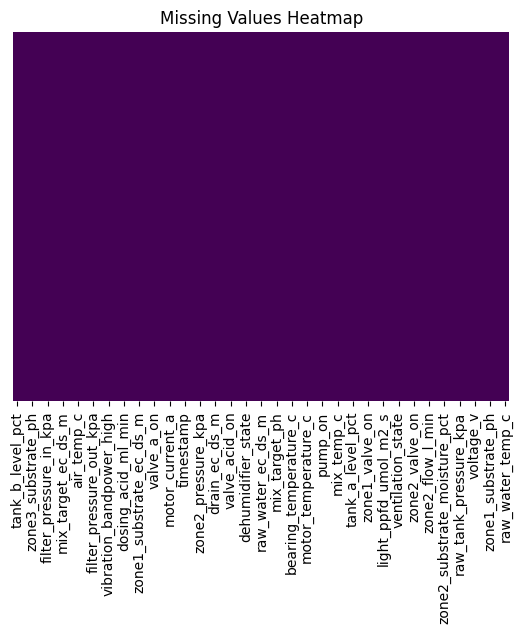

In [23]:
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

# 데이터 상관관계 확인

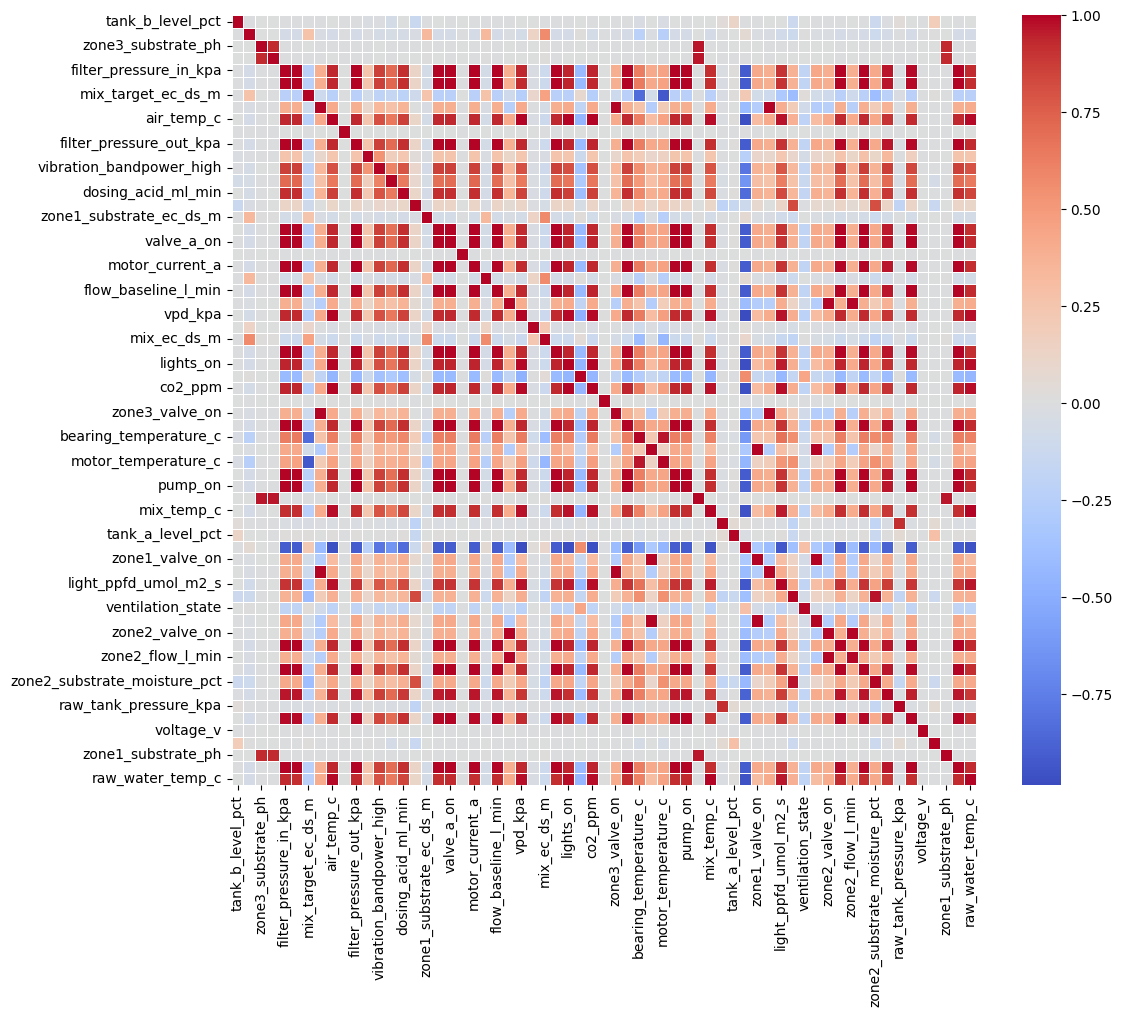

In [56]:
# 상관계수 계산
corr = df_raw.corr(numeric_only=True)

# 특정 기준(예: 상관계수 0.5) 이상의 관계가 하나라도 있는 컬럼만 추출
threshold = 0.5
high_corr_cols = corr.columns[(corr.abs() > threshold).any()]
filtered_corr = corr.loc[high_corr_cols, high_corr_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_corr, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.show()

In [57]:
# 2. 전체 상관계수 계산 (숫자형 + 수치화된 범주형)
corr_matrix = df_raw.corr(numeric_only=True).abs()

# 3. 상삼각 행렬만 추출
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [60]:
threshold = 0.7
high_corr_pairs = np.where(upper > threshold)

# 쌍(Pair) 리스트 생성
pairs = [(upper.index[i], upper.columns[j], upper.iloc[i, j]) 
        for i, j in zip(*high_corr_pairs)]

# 그룹화 (Dictionary 활용)
groups = {}
for p1, p2, val in pairs:
    if p1 not in groups: groups[p1] = []
    groups[p1].append(f"{p2}({val:.2f})")

print(f"--- [상관계수 {threshold} 이상] 연관 변수 그룹 ---")
if not groups:
    print("기준치를 넘는 고상관 변수가 없습니다.")
else:
    for key, values in groups.items():
        print(f"[{key}] 변수와 중복 위험: {', '.join(values)}\n")

--- [상관계수 0.7 이상] 연관 변수 그룹 ---
[zone3_substrate_ph] 변수와 중복 위험: zone2_substrate_ph(0.92), mix_ph(0.96), zone1_substrate_ph(0.93)

[zone2_substrate_ph] 변수와 중복 위험: mix_ph(0.96), zone1_substrate_ph(0.92)

[filter_pressure_in_kpa] 변수와 중복 위험: motor_power_kw(1.00), air_temp_c(0.94), filter_pressure_out_kpa(1.00), vibration_bandpower_high(0.87), turbidity_ntu(0.71), dosing_acid_ml_min(0.92), flow_rate_l_min(1.00), valve_a_on(1.00), motor_current_a(1.00), flow_baseline_l_min(1.00), vpd_kpa(0.93), valve_acid_on(1.00), lights_on(0.94), co2_ppm(0.94), discharge_pressure_kpa(1.00), mix_flow_l_min(1.00), pump_on(1.00), mix_temp_c(0.92), relative_humidity_pct(0.91), light_ppfd_umol_m2_s(0.90), valve_b_on(1.00), acoustic_db(1.00), bearing_vibration_peak_mm_s(0.96), suction_pressure_kpa(0.99), pump_rpm(1.00), raw_water_temp_c(0.92)

[motor_power_kw] 변수와 중복 위험: air_temp_c(0.94), filter_pressure_out_kpa(1.00), vibration_bandpower_high(0.87), turbidity_ntu(0.72), dosing_acid_ml_min(0.92), flow_rate_l_min(

In [65]:
compare_groups = {
    "Flow Rate Comparison (Zone 1 vs 2 vs 3)": [
        "zone1_flow_l_min", "zone2_flow_l_min", "zone3_flow_l_min"
    ],
    "Pressure Comparison (Zone 1 vs 2 vs 3)": [
        "zone1_pressure_kpa", "zone2_pressure_kpa", "zone3_pressure_kpa"
    ],
    "pH Comparison (Raw vs Mix vs Substrate)": [
        "raw_water_ph", "mix_ph", "zone1_substrate_ph", "zone2_substrate_ph", "zone3_substrate_ph"
    ],
    "EC Comparison (Raw vs Mix vs Substrate)": [
        "raw_water_ec_ds_m", "mix_ec_ds_m", "zone1_substrate_ec_ds_m", "zone2_substrate_ec_ds_m", "zone3_substrate_ec_ds_m"
    ],
    "Temperature Comparison": [
        "air_temp_c", "mix_temp_c", "raw_water_temp_c", "motor_temperature_c"
    ],
    "Tank Levels": [
        "raw_tank_level_pct", "tank_a_level_pct", "tank_b_level_pct", "acid_tank_level_pct"
    ],
    "Tank_pressure": [
        "filter_pressure_in_kpa", "filter_pressure_out_kpa","suction_pressure_kpa","discharge_pressure_kpa"
    ]

}

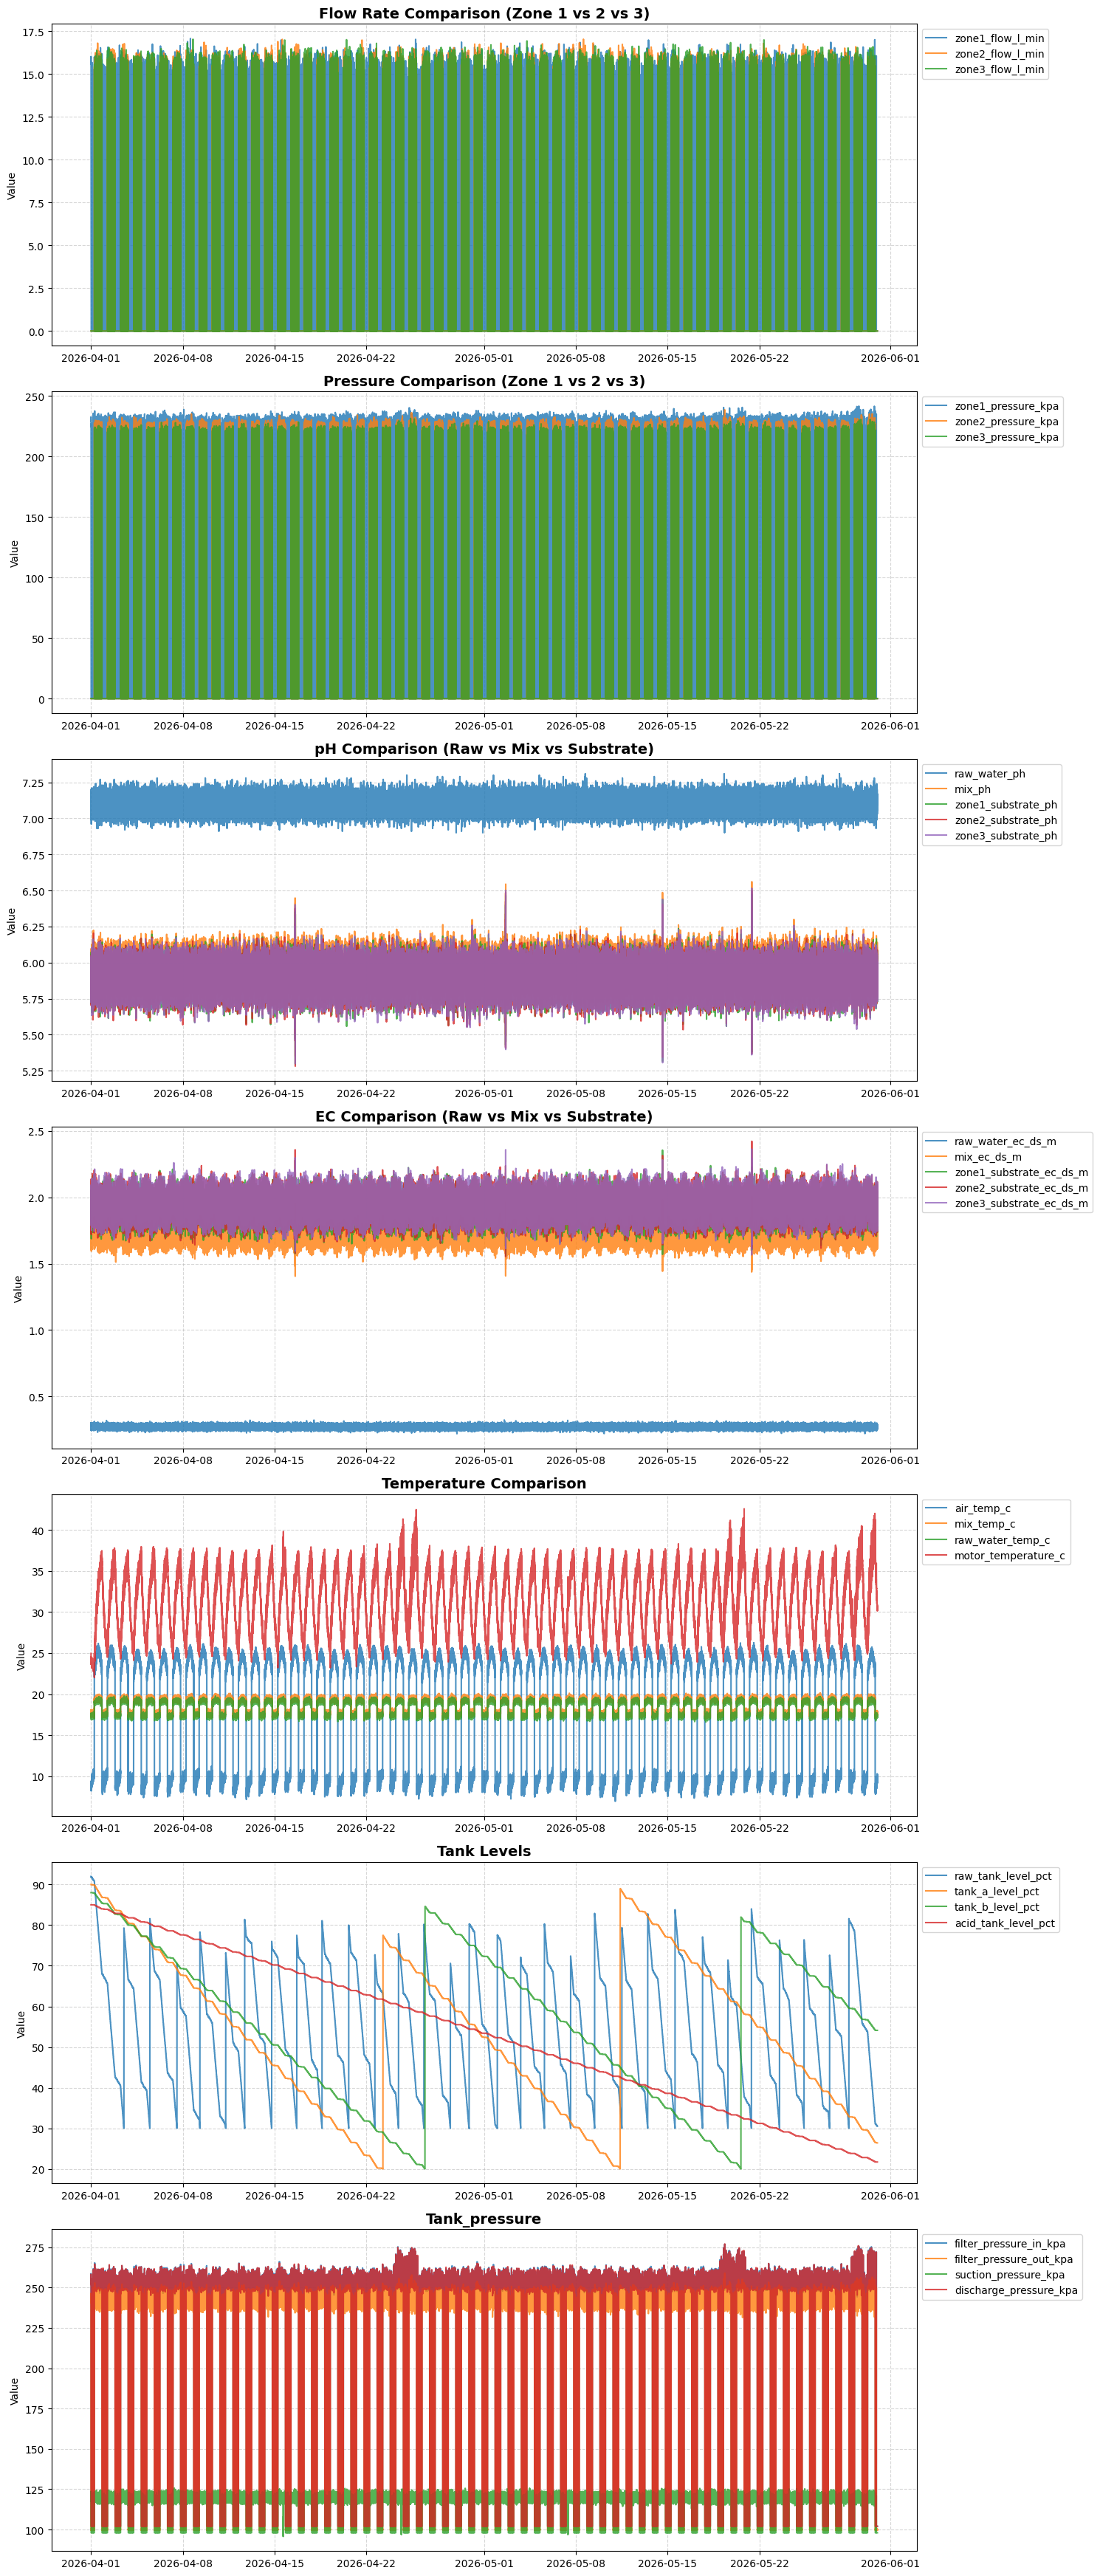

In [66]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))

# 데이터가 너무 많으면 그래프가 무거우니 1000개 정도만 샘플링해서 보기
# plot_df = df_raw.iloc[:1000] 
plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()